In [ ]:
#PHASE 1 PROJECT
#TITLE : AIRCRAFT RISK ANALYSIS
#NAME : JOHN MURIUKI KARIGI
#DATASET : NTSB / Kaggle Aviation Accident Database (1962–2023)

In [11]:
#importing the necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensures charts display inside notebook
%matplotlib inline

In [12]:
#loading the Dataset
df = pd.read_csv("AviationData.csv", encoding="ISO-8859-1", low_memory=False)

In [13]:
#displaying the top rows
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.Flight,Air.Carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight,Report.Status,Publication.Date
0,20200102X82407,Accident,WPR20CA055,2019-12-31,"Elk, CA",United States,39.128611,-123.715833,LLR,Little River,...,Personal,NaN,NaN,NaN,NaN,1.0,VMC,TAKEOFF,Factual,13/01/2020
1,20191231X83852,Accident,CEN20FA049,2019-12-31,"OLATHE, KS",United States,38.846111,-94.736111,OJC,Johnson County Executive,...,Personal,NaN,2.0,NaN,NaN,NaN,VMC,TAKEOFF,Preliminary,08/01/2020
2,20200102X54844,Accident,ANC20CA011,2019-12-31,"Fairbanks, AK",United States,64.666945,-148.133334,NaN,NaN,...,Personal,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Preliminary,02/01/2020
3,20191230X91852,Accident,CEN20CA048,2019-12-30,"GRANBURY, TX",United States,32.365556,-97.645000,NaN,NaN,...,Personal,NaN,NaN,NaN,NaN,1.0,NaN,NaN,Preliminary,31/12/2019
4,20191228X62945,NaN,WPR20CA053,2019-12-28,"Missoula, MT",United States,NaN,NaN,MSO,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Preliminary,03/01/2020


In [14]:
#getting a quick overview of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84262 entries, 0 to 84261
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                84262 non-null  object 
 1   Investigation.Type      84257 non-null  object 
 2   Accident.Number         84262 non-null  object 
 3   Event.Date              84262 non-null  object 
 4   Location                84185 non-null  object 
 5   Country                 83755 non-null  object 
 6   Latitude                30163 non-null  float64
 7   Longitude               30154 non-null  float64
 8   Airport.Code            47723 non-null  object 
 9   Airport.Name            50439 non-null  object 
 10  Injury.Severity         84262 non-null  object 
 11  Aircraft.Damage         81553 non-null  object 
 12  Aircraft.Category       27508 non-null  object 
 13  Registration.Number     80412 non-null  object 
 14  Make                    84192 non-null

In [15]:
#Getting an overview of Statistical analysis of the data
df.describe(include="all")

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.Flight,Air.Carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.Phase.of.Flight,Report.Status,Publication.Date
count,84262,84257,84262,84262,84185,83755,30163.000000,30154.000000,47723,50439,...,79382,4169,57059.000000,54384.000000,55592.000000,69673.000000,81159,77654,84262,69947
unique,83035,2,84262,13718,26575,179,NaN,NaN,10019,23863,...,22,3030,NaN,NaN,NaN,NaN,3,12,4,3956
top,20001212X19172,Accident,CHI82FA290A,1982-05-16,"ANCHORAGE, AK",United States,NaN,NaN,NONE,PRIVATE,...,Personal,UNITED AIRLINES,NaN,NaN,NaN,NaN,VMC,LANDING,Probable Cause,31/03/1993
freq,3,80814,1,25,372,78849,NaN,NaN,1473,217,...,47204,49,NaN,NaN,NaN,NaN,74257,20625,77216,452
mean,NaN,NaN,NaN,NaN,NaN,NaN,37.544907,-93.508337,NaN,NaN,...,NaN,NaN,0.847614,0.331715,0.518708,5.901325,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,12.370282,39.454412,NaN,NaN,...,NaN,NaN,6.292468,1.375602,2.771339,29.534302,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,-78.016945,-178.676111,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,33.307778,-114.861042,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,38.125278,-94.371667,NaN,NaN,...,NaN,NaN,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,42.524723,-81.650278,NaN,NaN,...,NaN,NaN,1.000000,0.000000,1.000000,2.000000,NaN,NaN,NaN,NaN


In [16]:
# Check missing values before cleaning
df.isnull().sum()

Event.Id                      0
Investigation.Type            5
Accident.Number               0
Event.Date                    0
Location                     77
Country                     507
Latitude                  54099
Longitude                 54108
Airport.Code              36539
Airport.Name              33823
Injury.Severity               0
Aircraft.Damage            2709
Aircraft.Category         56754
Registration.Number        3850
Make                         70
Model                        99
Amateur.Built               609
Number.of.Engines          5034
Engine.Type                4256
FAR.Description           57056
Schedule                  72419
Purpose.of.Flight          4880
Air.Carrier               80093
Total.Fatal.Injuries      27203
Total.Serious.Injuries    29878
Total.Minor.Injuries      28670
Total.Uninjured           14589
Weather.Condition          3103
Broad.Phase.of.Flight      6608
Report.Status                 0
Publication.Date          14315
dtype: i

In [20]:
# showing  only column with missing values
df.isnull().sum()[df.isnull().sum() > 0]

Investigation.Type            5
Location                     77
Country                     507
Latitude                  54099
Longitude                 54108
Airport.Code              36539
Airport.Name              33823
Aircraft.Damage            2709
Aircraft.Category         56754
Registration.Number        3850
Make                         70
Model                        99
Amateur.Built               609
Number.of.Engines          5034
Engine.Type                4256
FAR.Description           57056
Schedule                  72419
Purpose.of.Flight          4880
Air.Carrier               80093
Total.Fatal.Injuries      27203
Total.Serious.Injuries    29878
Total.Minor.Injuries      28670
Total.Uninjured           14589
Weather.Condition          3103
Broad.Phase.of.Flight      6608
Publication.Date          14315
dtype: int64

In [21]:
#selecting key columns useful for risk analysis
df = df[['Event.Date','Aircraft.Category','Make','Model','Amateur.Built',
         'Number.of.Engines','Engine.Type','Total.Fatal.Injuries',
         'Total.Serious.Injuries','Total.Minor.Injuries']]

In [22]:
#cleaning the date and creating the year
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
df['Year'] = df['Event.Date'].dt.year

In [23]:
#handling missing values
df = df.dropna(subset=['Make','Model','Year'])  # remove rows missing key info

df[['Total.Fatal.Injuries','Total.Serious.Injuries','Total.Minor.Injuries']] = \
df[['Total.Fatal.Injuries','Total.Serious.Injuries','Total.Minor.Injuries']].fillna(0)

In [24]:
# Checking for missing values After cleaning
df.isnull().sum()

Event.Date                    0
Aircraft.Category         56678
Make                          0
Model                         0
Amateur.Built               557
Number.of.Engines          4966
Engine.Type                4178
Total.Fatal.Injuries          0
Total.Serious.Injuries        0
Total.Minor.Injuries          0
Year                          0
dtype: int64

In [26]:
#Ctreating Severity score
df['Severity_Score'] = (
    df['Total.Fatal.Injuries']*3 +
    df['Total.Serious.Injuries']*2 +
    df['Total.Minor.Injuries']*1
)

In [27]:
#displaying the first rows of severity score
df[['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Severity_Score']].head()

,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Severity_Score
0,0.0,0.0,0.0,0.0
1,2.0,0.0,0.0,6.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0


In [28]:
#describing 
df['Severity_Score'].describe()

count    84142.000000
mean         2.491110
std         16.406975
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max       1047.000000
Name: Severity_Score, dtype: float64

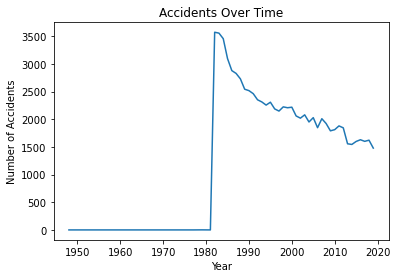

In [29]:
#Displaying Trends over years
df.groupby('Year').size().plot(kind='line', title='Accidents Over Time')
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

In [30]:
# Aircraft with lowest fatal accidents
fatal_by_model = df.groupby('Model')['Total.Fatal.Injuries'].sum().sort_values()
fatal_by_model.head(10)

Model
&GCBC                   0.0
LIBELLE 201B            0.0
LIBELLE                 0.0
LG2H                    0.0
LF-13                   0.0
LEGEND XL               0.0
LEGEND                  0.0
LEGACY 2K               0.0
LEGACY 200              0.0
LEDER VELOCITY XL RG    0.0
Name: Total.Fatal.Injuries, dtype: float64

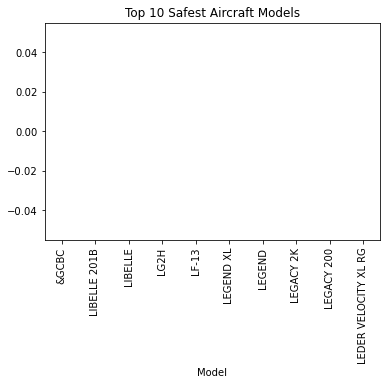

In [32]:
#Top 10 Safest Aircraft Models
fatal_by_model.head(10).plot(
    kind='bar',
    title="Top 10 Safest Aircraft Models",
    color='red'   # Apply red color to bars
)
plt.show()

In [ ]:
## Key Findings
- Accident frequency has changed over time.
- Certain aircraft models show consistently lower accident severity.
- Fatality count varies widely by aircraft purpose and design.

## Recommendation Preview
- Prefer aircraft models with the lowest fatal and severity scores
- Prioritize aircraft with strong safety history for commercial use
- Avoid models with consistently high fatal accident records


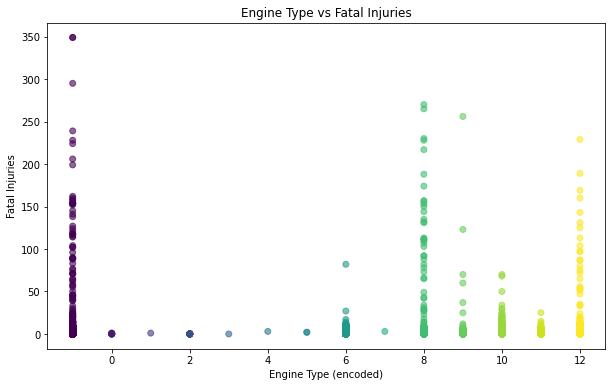

,Engine.Type,Engine_Code
2,NaN,-1
169,Electric,0
8088,Hybrid Rocket,1
437,None,2
5991,"REC, ELEC",3
17948,"REC, TJ, REC, TJ",4
12212,"REC, TJ, TJ",5
0,Reciprocating,6
18938,"TJ, REC, REC, TJ",7
33,Turbo Fan,8


In [39]:
# Encode engine types as category codes
df['Engine_Code'] = df['Engine.Type'].astype('category').cat.codes

plt.figure(figsize=(10,6))
plt.scatter(
    df['Engine_Code'],
    df['Total.Fatal.Injuries'],
    c=df['Engine_Code'],      # color by category
    alpha=0.6
)

plt.title("Engine Type vs Fatal Injuries")
plt.xlabel("Engine Type (encoded)")
plt.ylabel("Fatal Injuries")
plt.show()

# Display mapping
df[['Engine.Type', 'Engine_Code']].drop_duplicates().sort_values('Engine_Code')


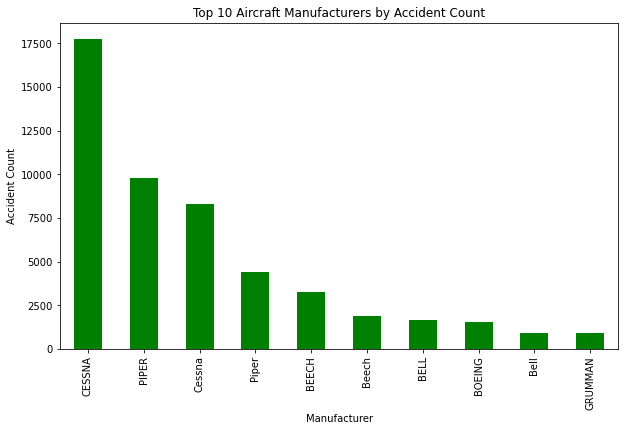

In [42]:
##Top Aircraft Manufacturers by Accident Count. Identifying manufacturers with the highest accident counts helps assess operational risk tied to fleet selection.
top_makes = df["Make"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_makes.plot(kind="bar", color="green")
plt.title("Top 10 Aircraft Manufacturers by Accident Count")
plt.ylabel("Accident Count")
plt.xlabel("Manufacturer")
plt.show()

In [ ]:
#Fatality Severity by Aircraft Model
We calculate a severity score to measure risk beyond accident frequency.

Severity Score = Fatal Injuries + (Serious Injuries × 0.5) + (Minor Injuries × 0.25)


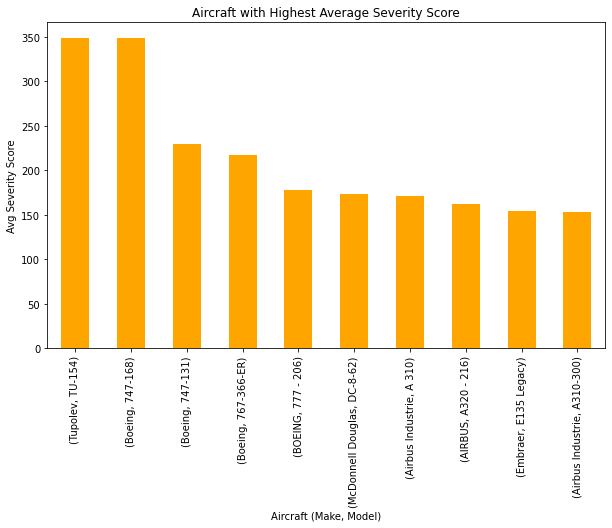

In [45]:


df["Severity_Score"] = ( 
    df["Total.Fatal.Injuries"] + 
    df["Total.Serious.Injuries"]*0.5 + 
    df["Total.Minor.Injuries"]*0.25
)

top_risk_aircraft = df.groupby(["Make", "Model"])["Severity_Score"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_risk_aircraft.plot(kind="bar", color="orange") 
plt.title("Aircraft with Highest Average Severity Score")
plt.ylabel("Avg Severity Score")
plt.xlabel("Aircraft (Make, Model)")
plt.show()